In [1]:
# =============================================================================
# 1. Импорт библиотек
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Для работы с дисбалансом (SMOTE)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_available = True
except ImportError:
    print("imbalanced-learn не установлен. SMOTE будет пропущен.")
    smote_available = False

# =============================================================================
# 2. Загрузка данных
# =============================================================================
df = pd.read_csv('model_data_after_rfm.csv')
print(f'Размер данных: {df.shape}')
print(df['data_split'].value_counts())

train_df = df[df['data_split'] == 'train'].drop(columns=['data_split']).copy()
test_df = df[df['data_split'] == 'test'].drop(columns=['data_split']).copy()

print(f'\nTrain: {train_df.shape}, отток: {train_df["churn"].mean():.2%}')
print(f'Test:  {test_df.shape}, отток: {test_df["churn"].mean():.2%}')


Размер данных: (29571, 128)
data_split
test     16203
train    13368
Name: count, dtype: int64

Train: (13368, 127), отток: 70.67%
Test:  (16203, 127), отток: 70.84%


In [ ]:
# =============================================================================
# 3. One-hot encoding категориальных признаков
# =============================================================================
import re
categorical_cols = ['client_type', 'country', 'okved', 'ecom_flg']

train_df['_split'] = 'train'
test_df['_split'] = 'test'
combined = pd.concat([train_df, test_df], ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

# ФИКС: pd.get_dummies возвращает bool-колонки, которые select_dtypes(include=[np.number])
bool_cols = combined_encoded.select_dtypes(include='bool').columns
print(f'Категориальных bool-колонок приведено к int: {len(bool_cols)}')
combined_encoded[bool_cols] = combined_encoded[bool_cols].astype(int)

def sanitize_columns(df):
    """LightGBM не разрешает символы '\"', ',', ':', '{', '}', '[', ']' в именах признаков -
    они попадают в дамми-колонки из названий okved. Заменяем на '_', схлопываем повторы,
    разруливаем возможные коллизии имён после очистки."""
    new_cols = []
    seen = {}
    for col in df.columns:
        clean = re.sub(r'[",:\{\}\[\]]', '_', str(col))
        clean = re.sub(r'\s+', '_', clean)          # обычные и неразрывные пробелы
        clean = re.sub(r'_+', '_', clean).strip('_')
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0
        new_cols.append(clean)
    df.columns = new_cols
    return df

train_encoded = combined_encoded[combined_encoded['_split'] == 'train'].drop(columns=['_split'])
test_encoded = combined_encoded[combined_encoded['_split'] == 'test'].drop(columns=['_split'])

train_encoded = sanitize_columns(train_encoded)
test_encoded = sanitize_columns(test_encoded)

Категориальных bool-колонок приведено к int: 1058


In [3]:
# =============================================================================
# 4. Удаление признаков с малой дисперсией
# =============================================================================
X_temp = train_encoded.drop('churn', axis=1).select_dtypes(include=[np.number]).fillna(0)
variances = X_temp.var()
threshold = 0.01
keep_cols = variances[variances > threshold].index.tolist()
print(f'Удалено {X_temp.shape[1] - len(keep_cols)} признаков с малой вариацией (по train)')

# =============================================================================
# 5. Удаление сильно коррелирующих признаков (>0.9)
# =============================================================================
corr_matrix = X_temp[keep_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
final_cols = [c for c in keep_cols if c not in to_drop]
print(f'Удалено {len(to_drop)} признаков из-за высокой корреляции (>0.9, по train)')
print(f'Итоговое число признаков: {len(final_cols)}')

Удалено 1041 признаков с малой вариацией (по train)
Удалено 33 признаков из-за высокой корреляции (>0.9, по train)
Итоговое число признаков: 102


In [4]:
# =============================================================================
# 6. Разделение на обучающую и тестовую выборки (стратифицированное)
# =============================================================================
X_train = train_encoded[final_cols]
y_train = train_encoded['churn']
X_test = test_encoded[final_cols]
y_test = test_encoded['churn']

print(f'Размер train: {X_train.shape}, test: {X_test.shape}')
print(f'Распределение churn в train:\n{y_train.value_counts(normalize=True)}')
print(f'Распределение churn в test:\n{y_test.value_counts(normalize=True)}')

Размер train: (13368, 102), test: (16203, 102)
Распределение churn в train:
churn
1    0.706688
0    0.293312
Name: proportion, dtype: float64
Распределение churn в test:
churn
1    0.708449
0    0.291551
Name: proportion, dtype: float64


In [5]:
# =============================================================================
# 7. Масштабирование для линейных моделей
# =============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


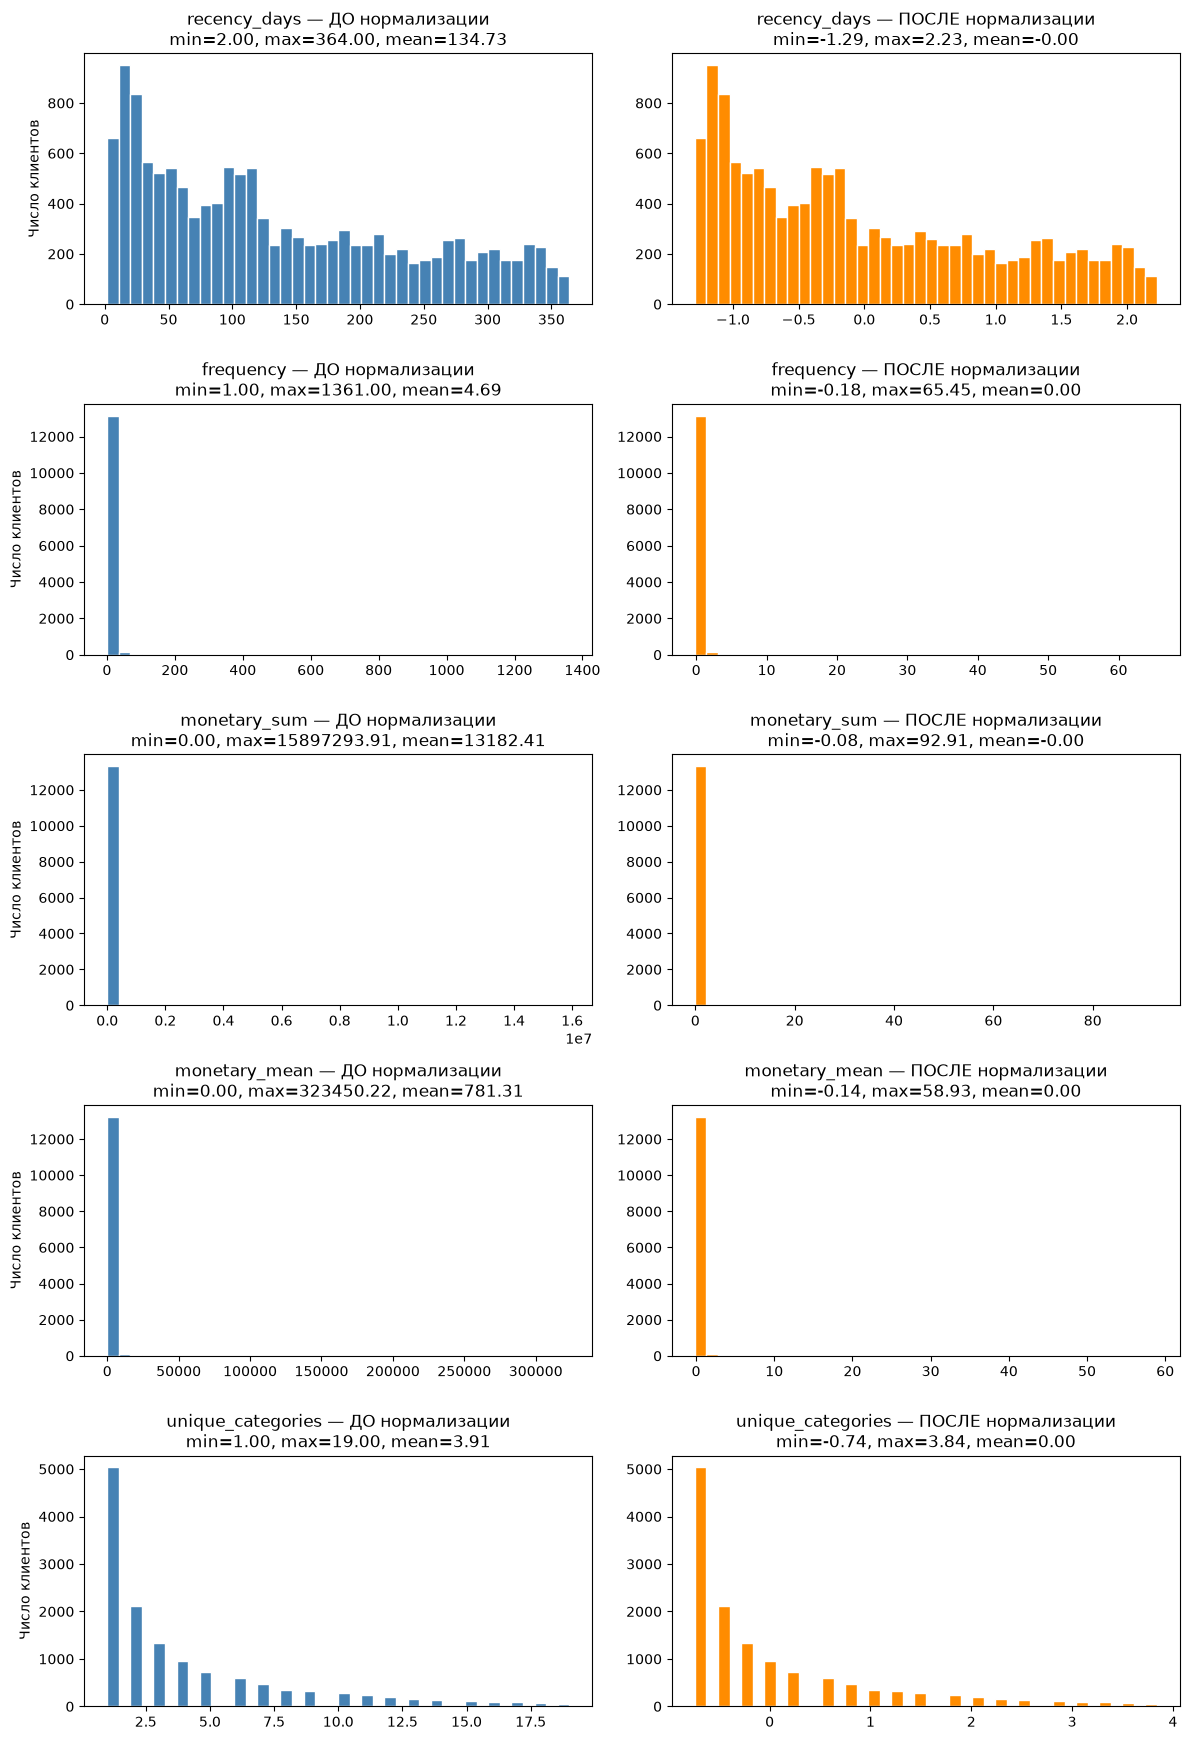

,Признак,min (до),max (до),min (после),max (после)
0,recency_days,2.0,3.640000e+02,-1.289,2.227
1,frequency,1.0,1.361000e+03,-0.178,65.448
2,monetary_sum,0.0,1.589729e+07,-0.077,92.913
3,monetary_mean,0.0,3.234502e+05,-0.143,58.932
4,unique_categories,1.0,1.900000e+01,-0.741,3.841


In [ ]:
# =============================================================================
# 8. Распределения признаков до и после нормализации (StandardScaler)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Несколько ключевых RFM-признаков для иллюстрации 
candidate_features = ['recency_days', 'frequency', 'monetary_sum', 'monetary_mean', 'unique_categories']
features_to_plot = [f for f in candidate_features if f in final_cols][:5]

fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(12, 3.5 * len(features_to_plot)))

for i, feat in enumerate(features_to_plot):
    col_idx = final_cols.index(feat)
    before = X_train[feat].values
    after = X_train_scaled[:, col_idx]

    axes[i, 0].hist(before, bins=40, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{feat} — ДО нормализации\nmin={before.min():.2f}, max={before.max():.2f}, mean={before.mean():.2f}')
    axes[i, 0].set_ylabel('Число клиентов')

    axes[i, 1].hist(after, bins=40, color='darkorange', edgecolor='white')
    axes[i, 1].set_title(f'{feat} — ПОСЛЕ нормализации\nmin={after.min():.2f}, max={after.max():.2f}, mean={after.mean():.2f}')

plt.tight_layout()
plt.savefig('normalization_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# Сводная таблица min/max по всем признакам
summary_rows = []
for feat in features_to_plot:
    col_idx = final_cols.index(feat)
    before = X_train[feat].values
    after = X_train_scaled[:, col_idx]
    summary_rows.append({
        'Признак': feat,
        'min (до)': before.min(), 'max (до)': before.max(),
        'min (после)': after.min(), 'max (после)': after.max(),
    })
display(pd.DataFrame(summary_rows).round(3))

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score

# recency_test — «дней с последнего заказа на дату среза» для клиентов из тестовой выборки
recency_test = X_test['recency_days']  

# 1. Бейзлайн как непрерывный скор риска (чем больше recency, тем выше риск оттока)
baseline_roc_auc = roc_auc_score(y_test, recency_test)
baseline_pr_auc = average_precision_score(y_test, recency_test)

# 2. Бейзлайн как жёсткое правило: не покупал дольше 147 дней -> отток
baseline_pred = (recency_test > 147).astype(int)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline ROC-AUC: {baseline_roc_auc:.4f}")
print(f"Baseline PR-AUC:  {baseline_pr_auc:.4f}")
print(f"Baseline Precision/Recall/F1/Accuracy: {baseline_precision:.4f} / {baseline_recall:.4f} / {baseline_f1:.4f} / {baseline_accuracy:.4f}")

Baseline ROC-AUC: 0.7650
Baseline PR-AUC:  0.8681
Baseline Precision/Recall/F1/Accuracy: 0.8585 / 0.6650 / 0.7494 / 0.6850


In [8]:
# Словарь для хранения вероятностей всех моделей
models_proba = {}

# Логистическая регрессия
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
models_proba['LogReg'] = logreg.predict_proba(X_test_scaled)[:, 1]

# Случайный лес
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models_proba['RandomForest'] = rf.predict_proba(X_test)[:, 1]

# XGBoost (базовый)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
xgb_base = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False,
    verbosity=0
)
xgb_base.fit(X_train, y_train)
models_proba['XGB_base'] = xgb_base.predict_proba(X_test)[:, 1]

# LightGBM
lgb_base = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)
lgb_base.fit(X_train, y_train)
models_proba['LGB_base'] = lgb_base.predict_proba(X_test)[:, 1]

In [9]:
# 9. Подбор гиперпараметров для XGBoost
# =============================================================================
print('\nНачинаем подбор гиперпараметров XGBoost...')
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_tune = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False,
    verbosity=0
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(xgb_tune, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print(f'Лучшие параметры: {grid.best_params_}')
best_xgb = grid.best_estimator_
# Сохраняем вероятности в словарь
models_proba['XGB_tuned'] = best_xgb.predict_proba(X_test)[:, 1]

# =============================================================================
# 10. Дополнительно: SMOTE (если доступен)
# =============================================================================
if smote_available:
    print('\nПрименяем SMOTE к XGBoost...')
    smote = SMOTE(random_state=42)
    pipeline = ImbPipeline([
        ('smote', smote),
        ('xgb', xgb.XGBClassifier(**grid.best_params_, random_state=42,
                                   eval_metric='aucpr', use_label_encoder=False, verbosity=0))
    ])
    pipeline.fit(X_train, y_train)
    y_proba_smote = pipeline.predict_proba(X_test)[:, 1]
    # Вычисляем метрики для SMOTE
    roc_smote = roc_auc_score(y_test, y_proba_smote)
    pr_smote = average_precision_score(y_test, y_proba_smote)
    # Сравниваем с XGB_tuned (берём из словаря)
    roc_tuned = roc_auc_score(y_test, models_proba['XGB_tuned'])
    pr_tuned = average_precision_score(y_test, models_proba['XGB_tuned'])
    print(f'\n===== XGBoost + SMOTE =====')
    print(f'ROC-AUC: {roc_smote:.4f}')
    print(f'PR-AUC:  {pr_smote:.4f}')
    print(f'SMOTE не дал улучшения: PR-AUC снизился с {pr_tuned:.4f} до {pr_smote:.4f}, ROC-AUC с {roc_tuned:.4f} до {roc_smote:.4f}.')
    print('XGBoost уже учитывает дисбаланс через scale_pos_weight, поэтому SMOTE не используется.\n')
    models_proba['XGB_SMOTE'] = y_proba_smote
else:
    print('\nSMOTE недоступен (imbalanced-learn не установлен).')
    best_model = best_xgb


Начинаем подбор гиперпараметров XGBoost...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Применяем SMOTE к XGBoost...

===== XGBoost + SMOTE =====
ROC-AUC: 0.8176
PR-AUC:  0.9011
SMOTE не дал улучшения: PR-AUC снизился с 0.9100 до 0.9011, ROC-AUC с 0.8341 до 0.8176.
XGBoost уже учитывает дисбаланс через scale_pos_weight, поэтому SMOTE не используется.




===== Сводная таблица метрик моделей =====
          Model  ROC-AUC  PR-AUC  Accuracy  Precision_0  Precision_1  \
0        LogReg   0.8259  0.9036    0.7837       0.6189       0.8602   
1  RandomForest   0.8103  0.8889    0.8025       0.6957       0.8363   
2      XGB_base   0.8209  0.9002    0.7900       0.6474       0.8445   
3      LGB_base   0.8201  0.8990    0.7904       0.6463       0.8465   
4     XGB_tuned   0.8341  0.9100    0.7817       0.6096       0.8680   
5     XGB_SMOTE   0.8176  0.9011    0.7799       0.6245       0.8425   

   Recall_0  Recall_1    F1_0    F1_1  
0    0.6723    0.8296  0.6445  0.8446  
1    0.5735    0.8968  0.6287  0.8655  
2    0.6141    0.8624  0.6303  0.8533  
3    0.6211    0.8601  0.6334  0.8533  
4    0.6986    0.8159  0.6511  0.8412  
5    0.6147    0.8479  0.6196  0.8452  

Лучшая модель по PR-AUC: XGB_tuned (PR-AUC = 0.9100)
===== Train vs Test: проверка на переобучение =====


,Model,ROC-AUC train,ROC-AUC test,ROC-AUC gap,PR-AUC train,PR-AUC test,PR-AUC gap,F1 train,F1 test,F1 gap
0,LogReg,0.8362,0.8259,0.0104,0.9121,0.9036,0.0084,0.8378,0.8446,-0.0068
1,RandomForest,1.0000,0.8103,0.1897,1.0000,0.8889,0.1111,0.9988,0.8655,0.1334
2,XGB_base,0.9614,0.8209,0.1404,0.9809,0.9002,0.0807,0.9387,0.8533,0.0854
3,XGB_tuned,0.8569,0.8341,0.0228,0.9247,0.9100,0.0147,0.8511,0.8412,0.0100
4,XGB_SMOTE,0.8472,0.8176,0.0296,0.9183,0.9011,0.0171,0.8734,0.8452,0.0282



Интерпретация: gap = train - test. Значения gap выше ~0.05-0.10 по ROC-AUC/PR-AUC
обычно указывают на заметное переобучение; малый и стабильный gap подтверждает,
что выбранная модель обобщается, а не просто запоминает обучающую выборку.

===== Сравнение метрик для XGB_tuned при порогах 0.5 и 0.29 =====
   Threshold  Accuracy  Precision_0  Precision_1  Recall_0  Recall_1    F1_0  \
0       0.50    0.7817       0.6096       0.8680    0.6986    0.8159  0.6511   
1       0.29    0.8115       0.7778       0.8192    0.4949    0.9418  0.6049   

     F1_1  
0  0.8412  
1  0.8762  


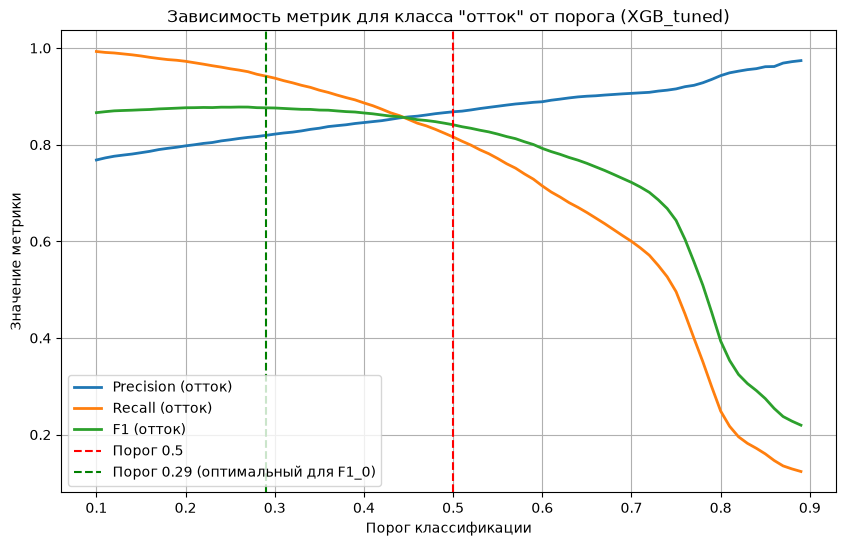


===== Интерпретация =====
1. Модель XGB_tuned выбрана как лучшая по PR-AUC (0.9100).
   PR-AUC не зависит от порога, поэтому выбор модели объективен.

2. Для выбранной модели проведён анализ зависимости метрик от порога.
   Рассмотрены два ключевых порога: стандартный 0.5 и оптимальный по F1 для класса 0 (лояльные) — 0.29.

   • При пороге 0.5: Precision_1 = 0.8680, Recall_1 = 0.8159
   • При пороге 0.29: Precision_1 = 0.8192, Recall_1 = 0.9418

   Интерпретация:
   - Порог 0.5 даёт более высокую точность (на 4.9 п.п.), т.е. меньше ложных срабатываний.
   - Порог 0.29 даёт более высокую полноту (на 12.6 п.п.), т.е. находит больше уходящих клиентов.
   - Однако рост полноты достигается ценой увеличения ложных тревог, что ведёт к дополнительным контактам с лояльными клиентами и росту издержек.

3. Выбор порога 0.5 обоснован бизнес-приоритетами:
   - Сохранение доверия лояльных клиентов (минимизация ошибочных коммуникаций).
   - Снижение нагрузки на отдел удержания и маркетинговые бюджет

In [10]:
# =============================================================================
# 11. Сводная таблица метрик моделей (без привязки к порогу)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score)

# Собираем метрики для всех моделей при пороге 0.5 (только для Accuracy, Precision, Recall, F1)
# ROC-AUC и PR-AUC не зависят от порога
threshold = 0.5
results = []
for name, proba in models_proba.items():
    y_pred = (proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=None)
    rec = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred, average=None)
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Accuracy': acc,
        'Precision_0': prec[0],
        'Precision_1': prec[1],
        'Recall_0': rec[0],
        'Recall_1': rec[1],
        'F1_0': f1[0],
        'F1_1': f1[1]
    })

df_results = pd.DataFrame(results)
print('\n===== Сводная таблица метрик моделей =====')
print(df_results.round(4))

# Определяем лучшую модель по PR-AUC (основной критерий при дисбалансе)
best_idx = df_results['PR-AUC'].idxmax()
best_model_name = df_results.loc[best_idx, 'Model']
best_pr_auc = df_results.loc[best_idx, 'PR-AUC']
print(f"\nЛучшая модель по PR-AUC: {best_model_name} (PR-AUC = {best_pr_auc:.4f})")
best_proba = models_proba[best_model_name]

# =============================================================================
# TRAIN vs TEST — проверка на переобучение для ключевых моделей
# =============================================================================
# Переиспользуем уже обученные объекты моделей (без повторного fit)
train_eval_models = {
    'LogReg':      (logreg,   X_train_scaled),
    'RandomForest': (rf,      X_train),
    'XGB_base':    (xgb_base, X_train),
    'XGB_tuned':   (best_xgb, X_train),
}
if smote_available and 'XGB_SMOTE' in models_proba:
    train_eval_models['XGB_SMOTE'] = (pipeline, X_train)

test_eval_models = {
    'LogReg':      (logreg,   X_test_scaled),
    'RandomForest': (rf,      X_test),
    'XGB_base':    (xgb_base, X_test),
    'XGB_tuned':   (best_xgb, X_test),
}
if smote_available and 'XGB_SMOTE' in models_proba:
    test_eval_models['XGB_SMOTE'] = (pipeline, X_test)

threshold = 0.5
overfit_rows = []
for name in train_eval_models:
    model_obj, X_tr = train_eval_models[name]
    _, X_te = test_eval_models[name]

    proba_train = model_obj.predict_proba(X_tr)[:, 1]
    proba_test = model_obj.predict_proba(X_te)[:, 1]

    roc_train = roc_auc_score(y_train, proba_train)
    roc_test = roc_auc_score(y_test, proba_test)
    pr_train = average_precision_score(y_train, proba_train)
    pr_test = average_precision_score(y_test, proba_test)
    f1_train = f1_score(y_train, (proba_train >= threshold).astype(int))
    f1_test = f1_score(y_test, (proba_test >= threshold).astype(int))

    overfit_rows.append({
        'Model': name,
        'ROC-AUC train': roc_train, 'ROC-AUC test': roc_test, 'ROC-AUC gap': roc_train - roc_test,
        'PR-AUC train': pr_train, 'PR-AUC test': pr_test, 'PR-AUC gap': pr_train - pr_test,
        'F1 train': f1_train, 'F1 test': f1_test, 'F1 gap': f1_train - f1_test,
    })

df_overfit = pd.DataFrame(overfit_rows).round(4)
print('===== Train vs Test: проверка на переобучение =====')
display(df_overfit)

print('\nИнтерпретация: gap = train - test. Значения gap выше ~0.05-0.10 по ROC-AUC/PR-AUC')
print('обычно указывают на заметное переобучение; малый и стабильный gap подтверждает,')
print('что выбранная модель обобщается, а не просто запоминает обучающую выборку.')

# =============================================================================
# 12. Сравнение порогов 0.5 и 0.29 для лучшей модели (XGB_tuned)
# =============================================================================
# Рассчитаем метрики для двух порогов
thresholds_compare = [0.5, 0.29]
comp_data = []
for th in thresholds_compare:
    y_pred = (best_proba >= th).astype(int)
    comp_data.append({
        'Threshold': th,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_0': precision_score(y_test, y_pred, pos_label=0),
        'Precision_1': precision_score(y_test, y_pred, pos_label=1),
        'Recall_0': recall_score(y_test, y_pred, pos_label=0),
        'Recall_1': recall_score(y_test, y_pred, pos_label=1),
        'F1_0': f1_score(y_test, y_pred, pos_label=0),
        'F1_1': f1_score(y_test, y_pred, pos_label=1)
    })
df_comp = pd.DataFrame(comp_data)
print('\n===== Сравнение метрик для XGB_tuned при порогах 0.5 и 0.29 =====')
print(df_comp.round(4))

# Визуализация зависимости метрик от порога для класса "отток" (класс 1)
thresholds = np.arange(0.1, 0.9, 0.01)
prec_1 = []
rec_1 = []
f1_1 = []
for th in thresholds:
    y_pred = (best_proba >= th).astype(int)
    prec_1.append(precision_score(y_test, y_pred, pos_label=1))
    rec_1.append(recall_score(y_test, y_pred, pos_label=1))
    f1_1.append(f1_score(y_test, y_pred, pos_label=1))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, prec_1, label='Precision (отток)', linewidth=2)
plt.plot(thresholds, rec_1, label='Recall (отток)', linewidth=2)
plt.plot(thresholds, f1_1, label='F1 (отток)', linewidth=2)
plt.axvline(0.5, color='red', linestyle='--', label='Порог 0.5')
plt.axvline(0.29, color='green', linestyle='--', label='Порог 0.29 (оптимальный для F1_0)')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title(f'Зависимость метрик для класса "отток" от порога ({best_model_name})')
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# 13. Обоснование выбора порога 0.5
# =============================================================================
print('\n===== Интерпретация =====')

# 1. Пояснение про выбор модели
print(f'1. Модель {best_model_name} выбрана как лучшая по PR-AUC ({best_pr_auc:.4f}).')
print('   PR-AUC не зависит от порога, поэтому выбор модели объективен.')

# 2. Выбор порога для лучшей модели
print('\n2. Для выбранной модели проведён анализ зависимости метрик от порога.')
print('   Рассмотрены два ключевых порога: стандартный 0.5 и оптимальный по F1 для класса 0 (лояльные) — 0.29.')

row_05 = df_comp[df_comp['Threshold'] == 0.5].iloc[0]
row_029 = df_comp[df_comp['Threshold'] == 0.29].iloc[0]
prec1_05 = row_05['Precision_1']
rec1_05 = row_05['Recall_1']
prec1_029 = row_029['Precision_1']
rec1_029 = row_029['Recall_1']

print(f'\n   • При пороге 0.5: Precision_1 = {prec1_05:.4f}, Recall_1 = {rec1_05:.4f}')
print(f'   • При пороге 0.29: Precision_1 = {prec1_029:.4f}, Recall_1 = {rec1_029:.4f}')

print('\n   Интерпретация:')
print(f'   - Порог 0.5 даёт более высокую точность (на {(prec1_05 - prec1_029)*100:.1f} п.п.), т.е. меньше ложных срабатываний.')
print(f'   - Порог 0.29 даёт более высокую полноту (на {(rec1_029 - rec1_05)*100:.1f} п.п.), т.е. находит больше уходящих клиентов.')
print('   - Однако рост полноты достигается ценой увеличения ложных тревог, что ведёт к дополнительным контактам с лояльными клиентами и росту издержек.')

print('\n3. Выбор порога 0.5 обоснован бизнес-приоритетами:')
print('   - Сохранение доверия лояльных клиентов (минимизация ошибочных коммуникаций).')
print('   - Снижение нагрузки на отдел удержания и маркетинговые бюджеты.')
print(f'   - Полнота оттока ({rec1_05*100:.1f}%) признана достаточной для практического применения.')
print('   - При необходимости порог может быть скорректирован в сторону понижения, если бизнес готов к увеличению ложных срабатываний.')

print('\nИтоговый вывод:')
print(f'Модель {best_model_name} с порогом 0.5 выбрана как оптимальное решение.')

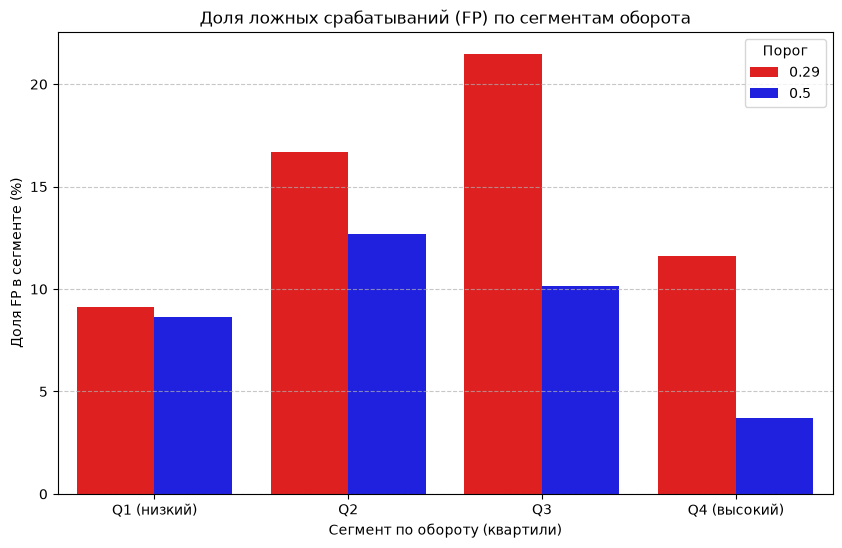

Общее количество ложных срабатываний:
  Порог 0.5: 1424 FP
  Порог 0.29: 2386 FP

===== Интерпретация =====
Доля ложных срабатываний по сегментам (%):
threshold            0.29    0.5
Сегмент по обороту              
Q1 (низкий)          9.13   8.61
Q2                  16.67  12.67
Q3                  21.48  10.17
Q4 (высокий)        11.63   3.70

При пороге 0.5:
  • Наибольшая доля FP – в сегменте "Q2" (12.67%)
  • Наименьшая доля FP – в сегменте "Q4 (высокий)" (3.70%)

При снижении порога до 0.29:
  • В сегменте "Q4 (высокий)" доля FP возрастает с 3.70% до 11.63% (прирост 7.93 п.п.)

Вывод:
- Порог 0.5 даёт меньше ложных срабатываний в целом и концентрирует их в сегментах с низким оборотом,
  что снижает риск для ключевых клиентов.
- Снижение порога до 0.29 увеличивает число ошибочных коммуникаций с ценными клиентами,
  что нежелательно с бизнес-точки зрения.
Таким образом, порог 0.5 остаётся предпочтительным.


In [11]:
# =============================================================================
# 14. Анализ ложных срабатываний по сегментам оборота
# =============================================================================

# Используем тестовую выборку
test_indices = X_test.index

# Создаём DataFrame с вероятностями, фактическими значениями и оборотом
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_proba': best_proba,
    'monetary': X_test['monetary_sum']
})

# Сегментируем по обороту (квартили)
df_eval['monetary_segment'] = pd.qcut(df_eval['monetary'], q=4, labels=['Q1 (низкий)', 'Q2', 'Q3', 'Q4 (высокий)'])

# Рассчитываем долю FP по сегментам для двух порогов
thresholds_to_compare = [0.5, 0.29]
fp_by_segment = {}

for th in thresholds_to_compare:
    df_eval['pred'] = (df_eval['y_proba'] >= th).astype(int)
    fp_mask = (df_eval['y_true'] == 0) & (df_eval['pred'] == 1)
    fp_count = df_eval[fp_mask].groupby('monetary_segment').size()
    total_in_segment = df_eval.groupby('monetary_segment').size()
    fp_rate = fp_count / total_in_segment * 100
    fp_by_segment[th] = fp_rate

# График
df_fp = pd.DataFrame(fp_by_segment).reset_index().melt(id_vars='monetary_segment', var_name='threshold', value_name='FP_rate')
df_fp.rename(columns={'monetary_segment': 'Сегмент по обороту'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fp, x='Сегмент по обороту', y='FP_rate', hue='threshold', palette=['red', 'blue'])
plt.title('Доля ложных срабатываний (FP) по сегментам оборота')
plt.ylabel('Доля FP в сегменте (%)')
plt.xlabel('Сегмент по обороту (квартили)')
plt.legend(title='Порог')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Общее количество FP
print('Общее количество ложных срабатываний:')
for th in thresholds_to_compare:
    pred = (df_eval['y_proba'] >= th).astype(int)
    fp_total = ((df_eval['y_true'] == 0) & (pred == 1)).sum()
    print(f'  Порог {th}: {fp_total} FP')

# =============================================================================
# Динамическая интерпретация
# =============================================================================
print('\n===== Интерпретация =====')

# Сводная таблица долей FP по сегментам
fp_pivot = df_fp.pivot(index='Сегмент по обороту', columns='threshold', values='FP_rate')
print('Доля ложных срабатываний по сегментам (%):')
print(fp_pivot.round(2))

# Анализ для порога 0.5
max_seg_05 = fp_pivot[0.5].idxmax()
max_val_05 = fp_pivot[0.5].max()
min_seg_05 = fp_pivot[0.5].idxmin()
min_val_05 = fp_pivot[0.5].min()

print(f'\nПри пороге 0.5:')
print(f'  • Наибольшая доля FP – в сегменте "{max_seg_05}" ({max_val_05:.2f}%)')
print(f'  • Наименьшая доля FP – в сегменте "{min_seg_05}" ({min_val_05:.2f}%)')

# Изменение при снижении порога до 0.29
# Найдём сегмент с наибольшим оборотом (обычно Q4)
high_seg = [seg for seg in fp_pivot.index if 'высокий' in seg or 'Q4' in seg][0]
q4_05 = fp_pivot.loc[high_seg, 0.5]
q4_029 = fp_pivot.loc[high_seg, 0.29]
growth = q4_029 - q4_05

print(f'\nПри снижении порога до 0.29:')
print(f'  • В сегменте "{high_seg}" доля FP возрастает с {q4_05:.2f}% до {q4_029:.2f}% (прирост {growth:.2f} п.п.)')

# Общий вывод
print('\nВывод:')
print('- Порог 0.5 даёт меньше ложных срабатываний в целом и концентрирует их в сегментах с низким оборотом,')
print('  что снижает риск для ключевых клиентов.')
print('- Снижение порога до 0.29 увеличивает число ошибочных коммуникаций с ценными клиентами,')
print('  что нежелательно с бизнес-точки зрения.')
print('Таким образом, порог 0.5 остаётся предпочтительным.')

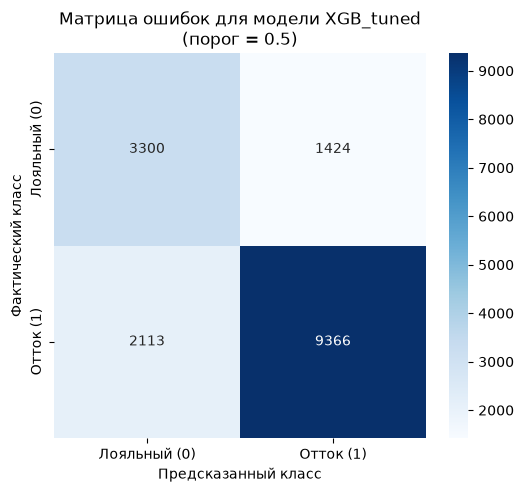


===== Интерпретация матрицы ошибок =====
• Истинно положительные (TP, верно предсказанный отток): 9366
• Истинно отрицательные (TN, верно предсказанные лояльные): 3300
• Ложноположительные (FP, ошибочно предсказанный отток для лояльных): 1424
• Ложноотрицательные (FN, пропущенный отток): 2113

При пороге 0.5:
  • Точность (Precision) для оттока: 86.80%
  • Полнота (Recall) для оттока: 81.59%
  • F1-мера для оттока: 84.12%


In [12]:
# =============================================================================
# 15. Визуализация матрицы ошибок для лучшей модели
# =============================================================================
y_pred_best = (best_proba >= threshold).astype(int)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_best)
class_names = ['Лояльный (0)', 'Отток (1)']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Матрица ошибок для модели {best_model_name}\n(порог = {threshold})')
plt.ylabel('Фактический класс')
plt.xlabel('Предсказанный класс')
plt.show()

# Интерпретация
tn, fp, fn, tp = cm.ravel()
print('\n===== Интерпретация матрицы ошибок =====')
print(f'• Истинно положительные (TP, верно предсказанный отток): {tp}')
print(f'• Истинно отрицательные (TN, верно предсказанные лояльные): {tn}')
print(f'• Ложноположительные (FP, ошибочно предсказанный отток для лояльных): {fp}')
print(f'• Ложноотрицательные (FN, пропущенный отток): {fn}')
print(f'\nПри пороге {threshold}:')
print(f'  • Точность (Precision) для оттока: {tp/(tp+fp):.2%}')
print(f'  • Полнота (Recall) для оттока: {tp/(tp+fn):.2%}')
print(f'  • F1-мера для оттока: {2*tp/(2*tp+fp+fn):.2%}')

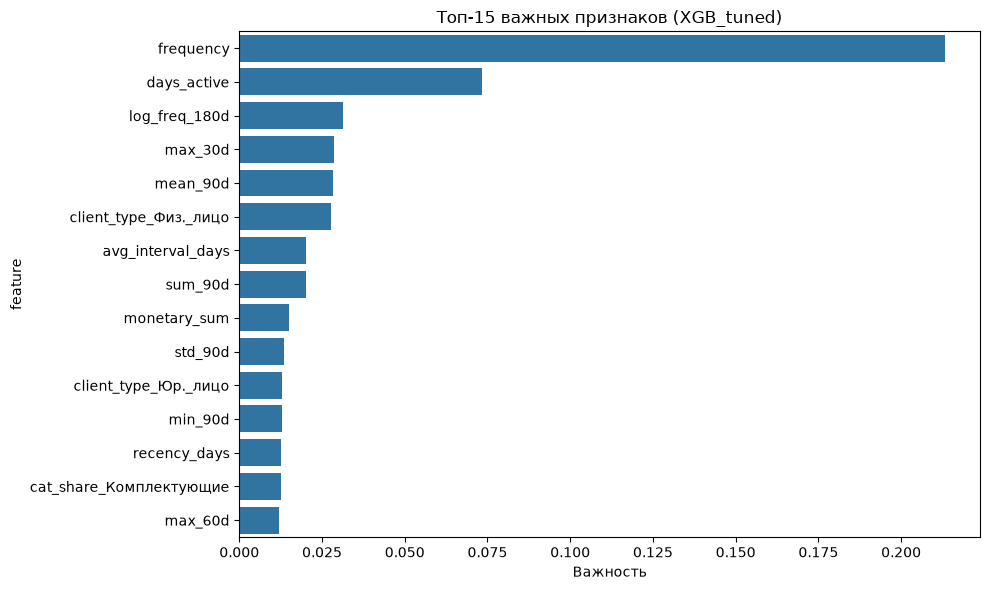


===== Заключение по категориальным признакам =====
Категориальные признаки, попавшие в топ-15: ['client_type_Физ._лицо', 'client_type_Юр._лицо']


In [13]:
# =============================================================================
# 16. Анализ важности признаков
# =============================================================================

if best_model_name in ['XGB_base', 'XGB_tuned', 'XGB_SMOTE']:
    # Определяем модель
    if best_model_name == 'XGB_tuned':
        model = best_xgb
    elif best_model_name == 'XGB_base':
        model = xgb_base
    elif best_model_name == 'XGB_SMOTE':
        model = pipeline.named_steps['xgb']
    
    if model is not None:
        importance = model.feature_importances_
        feature_names = X_train.columns
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=False)
        
        # Топ-15 признаков
        top_n = 15
        top_features = imp_df.head(top_n)
        
        # График важности
        plt.figure(figsize=(10, 6))
        sns.barplot(data=top_features, x='importance', y='feature')
        plt.title(f'Топ-{top_n} важных признаков ({best_model_name})')
        plt.xlabel('Важность')
        plt.tight_layout()
        plt.show()
        
        # Проверяем, есть ли категориальные признаки среди топ-15
        cat_cols_encoded = [col for col in feature_names if any(cat in col for cat in ['client_type', 'country', 'okved', 'ecom_flg'])]
        cat_in_top = [f for f in top_features['feature'] if f in cat_cols_encoded]
        
        print('\n===== Заключение по категориальным признакам =====')
        if not cat_in_top:
            print('Категориальные признаки (client_type, country, okved, ecom_flg) не вошли в топ-15 важных.')
            print('Это означает, что они не оказывают значимого влияния на предсказания модели.')
            print('Модель в основном опирается на поведенческие и денежные признаки (frequency, recency, monetary и др.).')
            print('One-hot кодирование не дало существенного улучшения качества модели.')
        else:
            print(f'Категориальные признаки, попавшие в топ-15: {cat_in_top}')